## lstm on imdb dataset

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb

In [5]:
(x_train,y_train),(x_test,y_test)=imdb.load_data(num_words=10000)
print(len(x_train))
print(len(x_test))

25000
25000


In [11]:
#normalize using padding sequence

from tensorflow.keras.preprocessing.sequence import pad_sequences
max_len=200  #forces each sequence to be exactly 200 length, agar kam hai to it adds 0's
x_train=pad_sequences(x_train,maxlen=max_len)
x_test=pad_sequences(x_test, maxlen=max_len)
print(x_train.shape)
print(x_test.shape)

(25000, 200)
(25000, 200)


In [12]:
#model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model=Sequential([
    Embedding(input_dim=10000, output_dim=64,input_length=200),
    LSTM(64),
    Dense(1,activation='sigmoid')
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
#compile + fine tune

model.compile(
    loss='binary_crossentropy', optimizer='adam',metrics=['accuracy']
)

In [14]:
#train model

history=model.fit(x_train,y_train, epochs=5, batch_size=64, validation_split=0.2)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 51s 146ms/step - accuracy: 0.7975 - loss: 0.4270 - val_accuracy: 0.8412 - val_loss: 0.3641
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 141ms/step - accuracy: 0.9017 - loss: 0.2497 - val_accuracy: 0.8700 - val_loss: 0.3078
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 145ms/step - accuracy: 0.9331 - loss: 0.1797 - val_accuracy: 0.8422 - val_loss: 0.3692
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 144ms/step - accuracy: 0.9520 - loss: 0.1334 - val_accuracy: 0.8652 - val_loss: 0.4043
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 141ms/step - accuracy: 0.9687 - loss: 0.0924 - val_accuracy: 0.8614 - val_loss: 0.4983


In [15]:
#predict on test

predic=model.predict(x_test)
predic=(predic>0.5).astype(int)
print(predic[:10])

782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 36ms/step
[[0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]]


In [16]:
#eval

loss,acc=model.evaluate(x_test,y_test)
print(loss)
print(acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - accuracy: 0.8517 - loss: 0.5395
0.53950434923172
0.8517199754714966


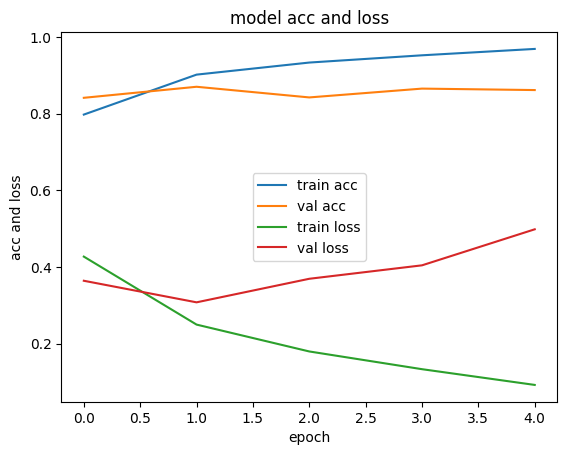

In [17]:
#viz acc vs loss

import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model acc and loss')
plt.legend(['train acc', 'val acc', 'train loss', 'val loss'])
plt.xlabel('epoch')
plt.ylabel('acc and loss')
plt.show()